# TP Final — Parte 2
## Preprocesamiento, Feature Engineering y Reducción de Dimensionalidad

**Materia:** Análisis de Datos — CEIA FIUBA (1B 2026)  
**Dataset:** Chicago Crimes 2025

---

### Objetivo

Este notebook implementa la **Parte 2** del trabajo práctico final, tomando como punto de partida el EDA desarrollado en `1.tp_final_eda_fran.ipynb`. Se cubren los tres bloques exigidos por la consigna:

1. **Preprocesamiento y limpieza**: limpieza general, split train/test, tratamiento de faltantes, manejo de outliers, escalado/normalización.
2. **Feature engineering**: creación de nuevas variables, codificación, discretización, análisis y tratamiento del desbalance de clases.
3. **Reducción de dimensionalidad**: selección de features por filtros y extracción con PCA.

### Definición del problema de ML

Se plantea un problema de **clasificación supervisada binaria**: predecir si un crimen resultará en arresto (`Arrest`) a partir del tipo de crimen, ubicación, contexto temporal y atributos auxiliares. La distribución observada en el EDA (~16% arrestos vs. ~84% sin arresto) caracteriza un problema desbalanceado, lo que motiva el uso de **split estratificado** y técnicas de balanceo sobre el conjunto de entrenamiento.

> **Nota.** La consigna explicita que el entrenamiento de modelos no es requisito. Todos los pasos de este notebook preparan los datos para un eventual paso de modelado posterior.


## 1. Setup y carga de datos

In [1]:
# Librerías base
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Preprocesamiento y modelado de datos
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, OrdinalEncoder, KBinsDiscretizer
)
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, chi2, f_classif, mutual_info_classif
)
from sklearn.decomposition import PCA

# Codificación avanzada
from category_encoders import OneHotEncoder, TargetEncoder

# Balance de clases
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 60)


### 1.1 Carga del dataset principal y enriquecimiento

Se reutiliza el flujo de la Parte 1: merge del dataset principal con la tabla de códigos **IUCR** (para recuperar `Index Code` y descripciones del delito) y con el dataset de **Community Areas** (para asociar el código numérico a su nombre).

In [2]:
# Dataset principal de crímenes
df = pd.read_csv('Crimes_-_2025_20260312.csv')

# Tabla de Community Areas (solo nombre)
community_areas = pd.read_csv(
    'Boundaries_-_Community_Areas_20260329.csv',
    usecols=['AREA_NUMBE', 'COMMUNITY']
).rename(columns={
    'AREA_NUMBE': 'Community Area',
    'COMMUNITY': 'Community Area Description'
})
community_areas['Community Area'] = community_areas['Community Area'].astype(int)

# Tabla de códigos IUCR
iucr_codes = pd.read_csv(
    'Chicago_Police_Department_-_Illinois_Uniform_Crime_Reporting_(IUCR)_Codes_20260329.csv'
).rename(columns={
    'PRIMARY DESCRIPTION': 'IUCR Primary',
    'SECONDARY DESCRIPTION': 'IUCR Secondary',
    'INDEX CODE': 'Index Code'
})
iucr_codes['IUCR'] = iucr_codes['IUCR'].str.zfill(4)

# Merge enriquecido
df_chicago = (
    df.merge(iucr_codes[['IUCR', 'IUCR Primary', 'IUCR Secondary', 'Index Code']],
             on='IUCR', how='left')
      .merge(community_areas, on='Community Area', how='left')
)

assert df.shape[0] == df_chicago.shape[0], 'El merge alteró la cantidad de filas'
print(f'Forma del dataset enriquecido: {df_chicago.shape}')
df_chicago.head()


Forma del dataset enriquecido: (236686, 26)


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,IUCR Primary,IUCR Secondary,Index Code,Community Area Description
0,14075483,JK105557,12/31/2025 11:58:00 PM,050XX S PAULINA ST,0560,ASSAULT,SIMPLE,RESIDENCE,False,False,931,9,20.0,61.0,08A,1165860.0,1871343.0,2025,01/09/2026 03:40:47 PM,41.802549,-87.667246,POINT (-87.667246428 41.802549018),ASSAULT,SIMPLE,N,NEW CITY
1,14070833,JK100050,12/31/2025 11:55:00 PM,053XX W WASHINGTON BLVD,0930,MOTOR VEHICLE THEFT,THEFT / RECOVERY - AUTOMOBILE,APARTMENT,False,True,1522,15,37.0,25.0,07,1140809.0,1900235.0,2025,01/08/2026 03:46:48 PM,41.882329,-87.758411,POINT (-87.758411303 41.882328854),MOTOR VEHICLE THEFT,THEFT / RECOVERY - AUTOMOBILE,I,AUSTIN
2,14070745,JK100011,12/31/2025 11:54:00 PM,100XX W OHARE ST,2890,PUBLIC PEACE VIOLATION,OTHER VIOLATION,AIRCRAFT,False,False,1651,16,41.0,76.0,24,1100658.0,1934241.0,2025,01/08/2026 03:46:48 PM,41.976290,-87.905227,POINT (-87.905227221 41.976290414),PUBLIC PEACE VIOLATION,OTHER VIOLATION,N,OHARE
3,14070845,JK100006,12/31/2025 11:54:00 PM,013XX W LAKE ST,0454,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",RESTAURANT,True,False,1215,12,27.0,28.0,08B,1167120.0,1901555.0,2025,01/08/2026 03:46:48 PM,41.885427,-87.661759,POINT (-87.661759042 41.885426714),BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",N,NEAR WEST SIDE
4,14070799,JK100014,12/31/2025 11:54:00 PM,100XX W OHARE ST,2890,PUBLIC PEACE VIOLATION,OTHER VIOLATION,AIRCRAFT,False,False,1651,16,41.0,76.0,24,1100658.0,1934241.0,2025,01/08/2026 03:46:48 PM,41.976290,-87.905227,POINT (-87.905227221 41.976290414),PUBLIC PEACE VIOLATION,OTHER VIOLATION,N,OHARE


### 1.2 Recordatorio de hallazgos del EDA

De la Parte 1 conservamos como puntos de partida:

- `Year` es **constante** (todo 2025) → no aporta información y se descarta.
- `Location` es texto WKT derivado de `Latitude` / `Longitude` → redundante.
- `Description` reproduce información ya contenida en `Primary Type` + `IUCR`.
- Las coordenadas (`Latitude`, `Longitude`, `X Coordinate`, `Y Coordinate`) tienen ~91 registros faltantes con patrón **MCAR**.
- La variable target `Arrest` está desbalanceada (~16% positivos, ~84% negativos).
- Existen correlaciones altas entre variables geográficas (`District` ↔ `Ward`: +0.66; `District` ↔ `Community Area`: -0.48) que conviene tener en cuenta al seleccionar features.

---
## 2. Limpieza general

Criterios de eliminación de columnas:

| Columna | Motivo |
|---|---|
| `ID`, `Case Number` | Identificadores únicos, sin aporte predictivo |
| `Year` | Constante (2025) |
| `Location` | Derivado literal de `Latitude` + `Longitude` |
| `Updated On` | Timestamp administrativo |
| `Description` | Redundante con `Primary Type` + `IUCR Secondary` |
| `Block` | Alta cardinalidad (>30k), reemplazable por `Beat` / `District` |

También convertimos `Date` a `datetime`, estandarizamos los strings categóricos y chequeamos duplicados.

In [3]:
# Flag 'has_coords' ANTES de imputar — más adelante nos servirá como feature
df_chicago['has_coords'] = df_chicago[['Latitude', 'Longitude']].notna().all(axis=1).astype(int)

cols_drop = ['ID', 'Case Number', 'Year', 'Location', 'Updated On', 'Description', 'Block']
df_clean = df_chicago.drop(columns=cols_drop)

# Parseo de fechas
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

# Normalización básica de strings (manteniendo dtype object para ser compatible con SimpleImputer)
for col in ['Primary Type', 'Location Description', 'FBI Code', 'IUCR',
            'IUCR Primary', 'IUCR Secondary', 'Index Code',
            'Community Area Description']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].where(df_clean[col].notna(), np.nan)
        mask = df_clean[col].notna()
        df_clean.loc[mask, col] = df_clean.loc[mask, col].astype(str).str.strip().str.upper()

# Duplicados (por registro completo — los IDs ya fueron eliminados)
dups = df_clean.duplicated().sum()
print(f'Filas duplicadas: {dups}')
if dups > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f'Forma tras limpieza: {df_clean.shape}')
df_clean.dtypes


Filas duplicadas: 525
Forma tras limpieza: (236161, 20)


Date                          datetime64[ns]
IUCR                                  object
Primary Type                          object
Location Description                  object
Arrest                                  bool
Domestic                                bool
Beat                                   int64
District                               int64
Ward                                 float64
Community Area                       float64
FBI Code                              object
X Coordinate                         float64
Y Coordinate                         float64
Latitude                             float64
Longitude                            float64
IUCR Primary                          object
IUCR Secondary                        object
Index Code                            object
Community Area Description            object
has_coords                             int64
dtype: object

---
## 3. Split train / test (estratificado)

El split se realiza **antes** de cualquier imputación, codificación o escalado. Esto evita **data leakage**: si estimáramos medias, modas o categorías usando observaciones del test, la evaluación posterior quedaría contaminada.

Además se usa `stratify=y` porque la clase positiva (`Arrest=True`) ronda el 16%; un split aleatorio simple podría producir folds con proporciones sensiblemente distintas.

In [4]:
y = df_clean['Arrest'].astype(int)
X = df_clean.drop(columns=['Arrest'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print('\nProporción de clases en train:')
print(y_train.value_counts(normalize=True).round(4))
print('\nProporción de clases en test:')
print(y_test.value_counts(normalize=True).round(4))


X_train: (188928, 19) | X_test: (47233, 19)

Proporción de clases en train:
Arrest
0    0.8401
1    0.1599
Name: proportion, dtype: float64

Proporción de clases en test:
Arrest
0    0.8401
1    0.1599
Name: proportion, dtype: float64


---
## 4. Tratamiento de valores faltantes

Diagnóstico inicial sobre el conjunto de entrenamiento.

In [5]:
missing_pct = X_train.isna().mean().sort_values(ascending=False) * 100
missing_pct[missing_pct > 0].round(3).to_frame('% faltante')


,% faltante
Index Code,4.373
IUCR Secondary,4.373
IUCR Primary,4.373
Location Description,0.474
Latitude,0.039
Longitude,0.039
X Coordinate,0.039
Y Coordinate,0.039
Community Area Description,0.001
Ward,0.001


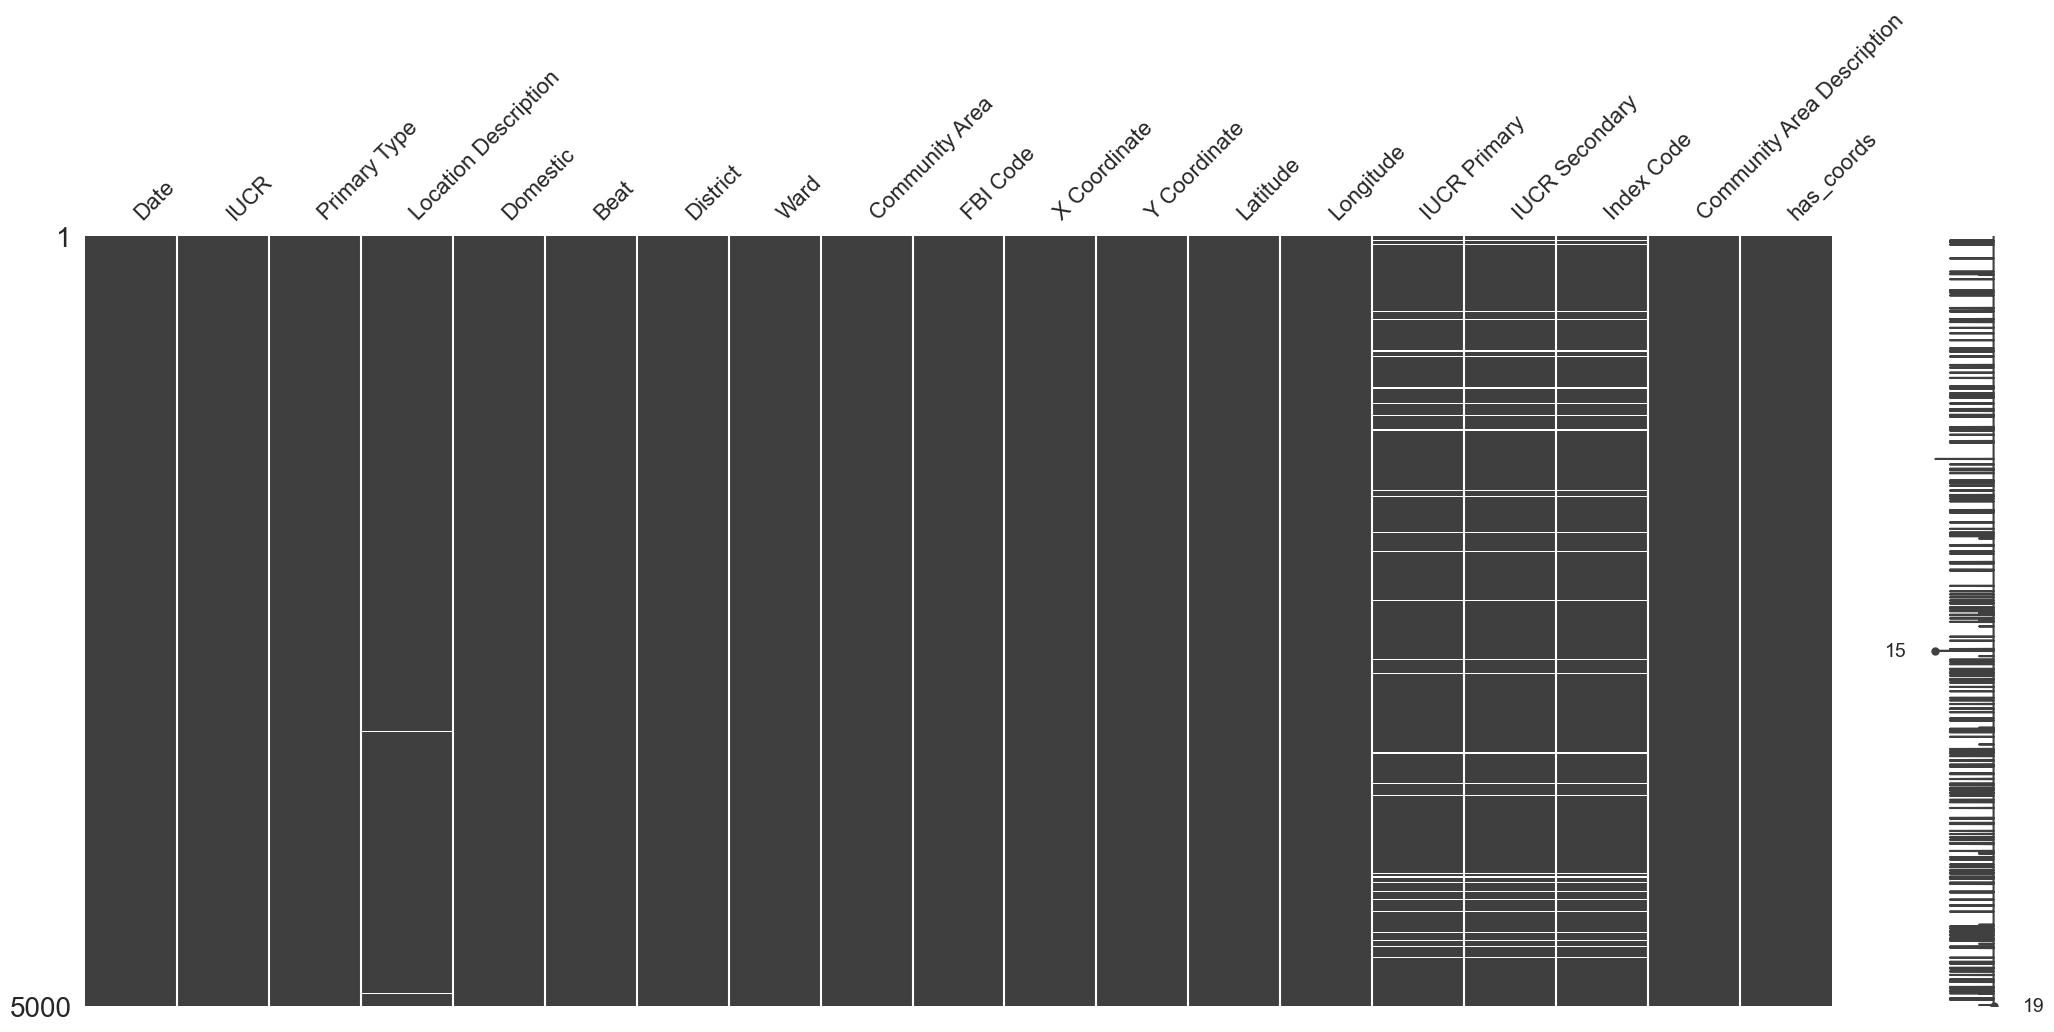

In [6]:
msno.matrix(X_train.sample(5000, random_state=RANDOM_STATE))
plt.show()


**Estrategia por tipo de variable:**

- **Coordenadas** (`Latitude`, `Longitude`, `X Coordinate`, `Y Coordinate`): 0.04% faltante, patrón MCAR (ver EDA). Se imputan con la **mediana** para no mover el centroide geográfico.
- **Códigos geográficos** (`Community Area`, `Ward`, `District`, `Beat`): se imputan con la **moda** (`most_frequent`) ya que son categorías codificadas como enteros.
- **Categóricos de texto** (`Location Description`, `IUCR Primary/Secondary`, `Index Code`, `Community Area Description`): se rellenan con la constante `'UNKNOWN'` para conservar el hecho de que el dato falta como categoría separada.

Se descarta `KNNImputer` porque el bajo porcentaje de faltantes no justifica su costo computacional sobre ~190k filas y requiere escalado previo.

In [7]:
num_coords = ['Latitude', 'Longitude', 'X Coordinate', 'Y Coordinate']
num_codes  = ['Community Area', 'Ward', 'District', 'Beat']
cat_text   = ['Location Description', 'IUCR Primary', 'IUCR Secondary',
              'Index Code', 'Community Area Description']

imp_median = SimpleImputer(strategy='median')
imp_mode   = SimpleImputer(strategy='most_frequent')
imp_unk    = SimpleImputer(strategy='constant', fill_value='UNKNOWN')

X_train[num_coords] = imp_median.fit_transform(X_train[num_coords])
X_test[num_coords]  = imp_median.transform(X_test[num_coords])

X_train[num_codes] = imp_mode.fit_transform(X_train[num_codes])
X_test[num_codes]  = imp_mode.transform(X_test[num_codes])

X_train[cat_text] = imp_unk.fit_transform(X_train[cat_text])
X_test[cat_text]  = imp_unk.transform(X_test[cat_text])

assert X_train[num_coords + num_codes + cat_text].isna().sum().sum() == 0
assert X_test[num_coords + num_codes + cat_text].isna().sum().sum() == 0
print('Imputación completada. Faltantes restantes (por columna):')
print(X_train.isna().sum()[X_train.isna().sum() > 0])


Imputación completada. Faltantes restantes (por columna):
Series([], dtype: int64)


---
## 5. Detección y manejo de outliers

Nos enfocamos únicamente en variables **continuas reales**: las coordenadas. `Beat`, `District`, `Ward` y `Community Area`, aunque numéricas, son códigos categóricos y sus valores "extremos" son categorías legítimas.

**Técnica:** IQR (`Q1 − 1.5·IQR`, `Q3 + 1.5·IQR`) calculado **sobre el train** y aplicado por `np.clip` (winsorización) a train y test. Se decide no eliminar filas porque las zonas periféricas de Chicago son geográficamente legítimas; eliminarlas sesgaría el análisis territorial.

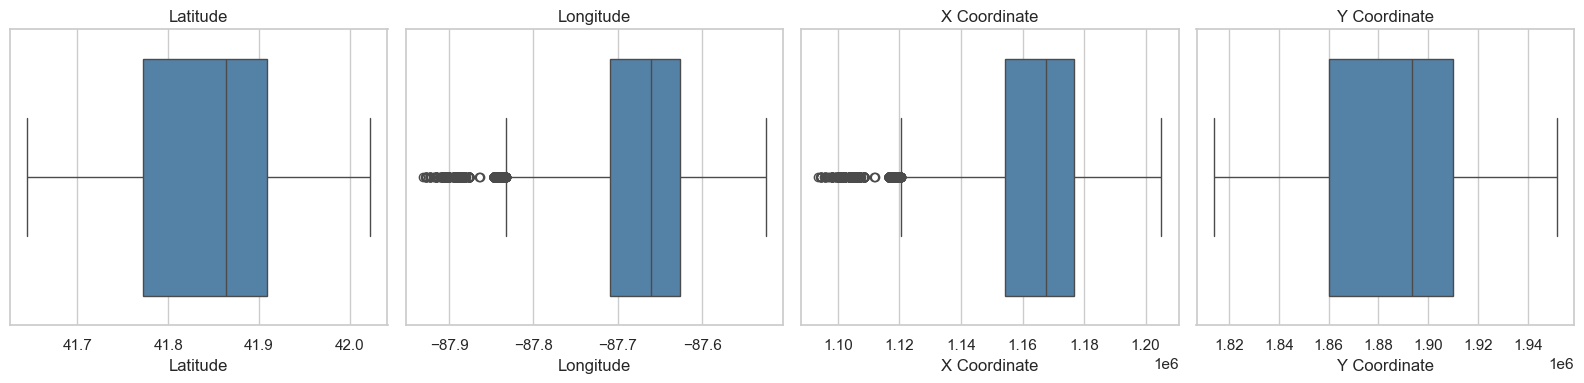

,Latitude,Longitude,X Coordinate,Y Coordinate
count,188928.000,188928.000,188928.000,188928.000
mean,41.846,-87.668,1165659.780,1887133.512
std,0.086,0.059,16270.278,31417.554
min,41.645,-87.931,1093568.000,1813897.000
25%,41.772,-87.709,1154292.000,1860174.000
50%,41.864,-87.660,1167639.000,1893567.000
75%,41.908,-87.626,1176884.000,1909888.000
max,42.023,-87.525,1205117.000,1951517.000


In [8]:
num_continuas = num_coords

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, num_continuas):
    sns.boxplot(x=X_train[col], ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

X_train[num_continuas].describe().round(3)


In [9]:
limites = {}
for col in num_continuas:
    q1, q3 = X_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    limites[col] = (lo, hi)
    n_out = ((X_train[col] < lo) | (X_train[col] > hi)).sum()
    print(f'{col}: {n_out:>5} outliers | lim=[{lo:.3f}, {hi:.3f}]')

# Winsorización con límites calculados en TRAIN
for col, (lo, hi) in limites.items():
    X_train[col] = X_train[col].clip(lo, hi)
    X_test[col]  = X_test[col].clip(lo, hi)


Latitude:     0 outliers | lim=[41.567, 42.114]
Longitude:  1434 outliers | lim=[-87.833, -87.503]
X Coordinate:  1430 outliers | lim=[1120404.000, 1210772.000]
Y Coordinate:     0 outliers | lim=[1785603.000, 1984459.000]


---
## 6. Feature engineering

Se crean variables nuevas que explotan información latente en `Date` y en las categorías de crimen. Todos los mapeos (rates por `Beat`) se aprenden **únicamente sobre el train**.

**Features temporales** (de `Date`):

- `hour`, `day_of_week`, `month`, `quarter`, `day_of_year`
- `is_weekend`, `is_night` (22 – 6 h)
- Encoding cíclico: `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos` (para capturar la periodicidad)

**Features derivados de tipo de crimen**: flags `is_violent` y `is_property` basados en la categorización estándar del FBI.

**Feature de frecuencia**: `beat_crime_rate` = cantidad de crímenes por `Beat` en el train.

In [10]:
def build_time_features(df_):
    out = df_.copy()
    d = out['Date']
    out['hour']         = d.dt.hour
    out['day_of_week']  = d.dt.dayofweek
    out['month']        = d.dt.month
    out['quarter']      = d.dt.quarter
    out['day_of_year']  = d.dt.dayofyear
    out['is_weekend']   = (out['day_of_week'] >= 5).astype(int)
    out['is_night']     = ((out['hour'] >= 22) | (out['hour'] < 6)).astype(int)
    out['hour_sin'] = np.sin(2 * np.pi * out['hour'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * out['hour'] / 24)
    out['dow_sin']  = np.sin(2 * np.pi * out['day_of_week'] / 7)
    out['dow_cos']  = np.cos(2 * np.pi * out['day_of_week'] / 7)
    return out

X_train = build_time_features(X_train)
X_test  = build_time_features(X_test)

X_train[['hour', 'day_of_week', 'month', 'quarter',
         'is_weekend', 'is_night', 'hour_sin', 'hour_cos']].head()


,hour,day_of_week,month,quarter,is_weekend,is_night,hour_sin,hour_cos
66215,15,1,9,3,0,0,-0.707107,-0.707107
210830,9,2,2,1,0,0,0.707107,-0.707107
114215,13,2,7,3,0,0,-0.258819,-0.965926
198334,17,2,3,1,0,0,-0.965926,-0.258819
208939,20,5,2,1,1,0,-0.866025,0.500000


In [11]:
VIOLENT = {'HOMICIDE', 'ASSAULT', 'BATTERY', 'ROBBERY', 'CRIM SEXUAL ASSAULT',
           'CRIMINAL SEXUAL ASSAULT', 'KIDNAPPING'}
PROPERTY = {'THEFT', 'BURGLARY', 'MOTOR VEHICLE THEFT', 'ARSON',
            'CRIMINAL DAMAGE', 'CRIMINAL TRESPASS'}

X_train['is_violent']  = X_train['Primary Type'].isin(VIOLENT).astype(int)
X_train['is_property'] = X_train['Primary Type'].isin(PROPERTY).astype(int)
X_test['is_violent']   = X_test['Primary Type'].isin(VIOLENT).astype(int)
X_test['is_property']  = X_test['Primary Type'].isin(PROPERTY).astype(int)

# Frecuencia de crímenes por Beat (aprendida en TRAIN)
beat_rate_map = X_train['Beat'].value_counts().to_dict()
fallback      = float(np.median(list(beat_rate_map.values())))
X_train['beat_crime_rate'] = X_train['Beat'].map(beat_rate_map).fillna(fallback)
X_test['beat_crime_rate']  = X_test['Beat'].map(beat_rate_map).fillna(fallback)

# Ya explotamos Date y IUCR (redundante con Primary Type + FBI Code)
X_train = X_train.drop(columns=['Date', 'IUCR'])
X_test  = X_test.drop(columns=['Date', 'IUCR'])

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
X_train.head(3)


X_train: (188928, 31) | X_test: (47233, 31)


,Primary Type,Location Description,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Latitude,Longitude,IUCR Primary,IUCR Secondary,Index Code,Community Area Description,has_coords,hour,day_of_week,month,quarter,day_of_year,is_weekend,is_night,hour_sin,hour_cos,dow_sin,dow_cos,is_violent,is_property,beat_crime_rate
66215,BATTERY,PARKING LOT / GARAGE (NON RESIDENTIAL),True,1421.0,14.0,26.0,23.0,08B,1154565.0,1910454.0,41.910107,-87.707625,BATTERY,DOMESTIC BATTERY SIMPLE,N,HUMBOLDT PARK,1,15,1,9,3,259,0,0,-0.707107,-0.707107,0.781831,0.623490,1,0,405
210830,NARCOTICS,SIDEWALK,False,2535.0,25.0,36.0,23.0,18,1151406.0,1907744.0,41.902733,-87.719301,NARCOTICS,MANUFACTURE / DELIVER - CANNABIS OVER 10 GRAMS,N,HUMBOLDT PARK,1,9,2,2,1,43,0,0,0.707107,-0.707107,0.974928,-0.222521,0,0,662
114215,ASSAULT,SIDEWALK,False,631.0,6.0,8.0,44.0,04A,1183631.0,1851826.0,41.748596,-87.602681,ASSAULT,AGGRAVATED - KNIFE / CUTTING INSTRUMENT,I,CHATHAM,1,13,2,7,3,190,0,0,-0.258819,-0.965926,0.974928,-0.222521,1,0,1229


---
## 7. Codificación de variables categóricas

Estrategia por cardinalidad:

| Variable | Cardinalidad | Técnica | Motivo |
|---|---|---|---|
| `Domestic` | 2 | cast a int | Booleano |
| `Index Code` | 2 | `OrdinalEncoder` | Categoría binaria I/N |
| `Primary Type`, `FBI Code`, `Location Description` (top-20 + OTHER), `IUCR Primary` | baja | `OneHotEncoder` | Preservar interpretabilidad |
| `Beat`, `Community Area`, `Ward`, `Community Area Description`, `IUCR Secondary` | alta (>50) | `TargetEncoder` | Evitar explosión dimensional |

> **Pitfall.** `TargetEncoder` se ajusta con `y_train` — **nunca** con `y_test`.

In [12]:
# Domestic booleano
X_train['Domestic'] = X_train['Domestic'].astype(int)
X_test['Domestic']  = X_test['Domestic'].astype(int)

# Index Code (I/N) — ordinal binaria
oe_index = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[['Index Code']] = oe_index.fit_transform(X_train[['Index Code']])
X_test[['Index Code']]  = oe_index.transform(X_test[['Index Code']])

# Reducir cardinalidad de Location Description a top-20 + OTHER
top_loc = X_train['Location Description'].value_counts().head(20).index
X_train['Location Description'] = X_train['Location Description'].where(
    X_train['Location Description'].isin(top_loc), 'OTHER')
X_test['Location Description'] = X_test['Location Description'].where(
    X_test['Location Description'].isin(top_loc), 'OTHER')


In [13]:
# One-Hot Encoding de baja cardinalidad
cat_ohe = ['Primary Type', 'FBI Code', 'Location Description', 'IUCR Primary']
ohe = OneHotEncoder(cols=cat_ohe, use_cat_names=True, handle_unknown='value', handle_missing='value')
X_train = ohe.fit_transform(X_train)
X_test  = ohe.transform(X_test)

print(f'Tras OHE — X_train: {X_train.shape} | X_test: {X_test.shape}')


Tras OHE — X_train: (188928, 136) | X_test: (47233, 136)


In [14]:
# Target Encoding de alta cardinalidad (fit con y_train)
cat_te = ['Beat', 'Community Area', 'Ward', 'Community Area Description', 'IUCR Secondary']
te = TargetEncoder(cols=cat_te, smoothing=10.0)
X_train = te.fit_transform(X_train, y_train)
X_test  = te.transform(X_test)

print(f'Tras Target Encoding — X_train: {X_train.shape} | X_test: {X_test.shape}')
X_train[cat_te].describe().round(4)


Tras Target Encoding — X_train: (188928, 136) | X_test: (47233, 136)


,Beat,Community Area,Ward,Community Area Description,IUCR Secondary
count,188928.0000,188928.0000,188928.0000,188928.0000,188928.0000
mean,0.1599,0.1599,0.1599,0.1599,0.1588
std,0.0725,0.0557,0.0434,0.0557,0.2306
min,0.0406,0.0569,0.0616,0.0569,0.0000
25%,0.1179,0.1227,0.1316,0.1227,0.0262
50%,0.1506,0.1502,0.1569,0.1502,0.0631
75%,0.1824,0.1893,0.1775,0.1893,0.2042
max,0.4746,0.3141,0.2975,0.3141,0.9911


---
## 8. Discretización

La discretización (binning) permite:

- Capturar relaciones **no lineales** entre features y target.
- Reducir la sensibilidad a outliers.
- Aportar variables ordinales interpretables (e.g. franjas horarias).

Aplicamos:

- `hour` → `time_of_day` en 4 cuartiles (quantile binning).
- `Latitude` / `Longitude` → 10 bins uniformes cada una para construir una grilla geográfica.

In [15]:
kb_hour = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
X_train['time_of_day'] = kb_hour.fit_transform(X_train[['hour']]).astype(int)
X_test['time_of_day']  = kb_hour.transform(X_test[['hour']]).astype(int)

kb_geo = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform')
X_train[['lat_bin', 'lon_bin']] = kb_geo.fit_transform(X_train[['Latitude', 'Longitude']]).astype(int)
X_test[['lat_bin', 'lon_bin']]  = kb_geo.transform(X_test[['Latitude', 'Longitude']]).astype(int)

print('time_of_day (value_counts):')
print(X_train['time_of_day'].value_counts().sort_index())


time_of_day (value_counts):
time_of_day
0    45380
1    41875
2    48478
3    53195
Name: count, dtype: int64


---
## 9. Escalado / normalización

Aplicamos **dos escaladores** sobre las features numéricas continuas para poder usar cada uno donde más conviene:

- **`StandardScaler`** (media 0, std 1): preferido para algoritmos sensibles a la escala como SVM, KNN o PCA (ver §12).
- **`MinMaxScaler`** ([0, 1]): necesario para **`chi2`** en la selección de features (§11), que exige valores no negativos.

Las variables categóricas ya transformadas (OHE, target-encoded, ordinales) no se re-escalan.

In [16]:
num_scale = [
    'Latitude', 'Longitude', 'X Coordinate', 'Y Coordinate',
    'District', 'Ward', 'Beat', 'Community Area',
    'Index Code',
    'Beat', 'Community Area', 'Ward', 'Community Area Description', 'IUCR Secondary',
    'hour', 'day_of_week', 'month', 'quarter', 'day_of_year',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'beat_crime_rate', 'time_of_day', 'lat_bin', 'lon_bin',
]
# Limpieza de duplicados manteniendo orden
num_scale = list(dict.fromkeys([c for c in num_scale if c in X_train.columns]))

# Versión estandarizada
std_scaler = StandardScaler()
X_train_std = X_train.copy()
X_test_std  = X_test.copy()
X_train_std[num_scale] = std_scaler.fit_transform(X_train[num_scale])
X_test_std[num_scale]  = std_scaler.transform(X_test[num_scale])

# Versión MinMax (para chi2)
mm_scaler = MinMaxScaler()
X_train_mm = X_train.copy()
X_test_mm  = X_test.copy()
X_train_mm[num_scale] = mm_scaler.fit_transform(X_train[num_scale])
X_test_mm[num_scale]  = mm_scaler.transform(X_test[num_scale])

X_train_std[num_scale].describe().loc[['mean', 'std', 'min', 'max']].round(3).T.head(10)


,mean,std,min,max
Latitude,-0.0,1.0,-2.330,2.045
Longitude,0.0,1.0,-2.844,2.455
X Coordinate,-0.0,1.0,-2.839,2.465
Y Coordinate,-0.0,1.0,-2.331,2.049
District,0.0,1.0,-1.444,2.797
Ward,-0.0,1.0,-2.263,3.171
Beat,-0.0,1.0,-1.645,4.340
Community Area,-0.0,1.0,-1.849,2.769
Index Code,0.0,1.0,-1.144,2.409
Community Area Description,0.0,1.0,-1.849,2.769


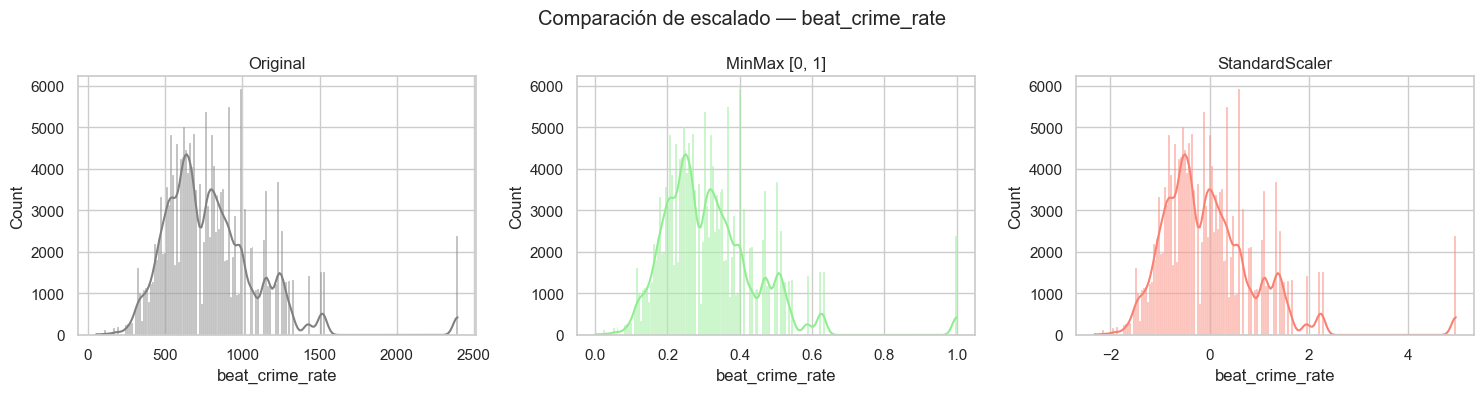

In [17]:
# Visualización comparativa sobre una variable representativa
col = 'beat_crime_rate'
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(X_train[col],      kde=True, ax=axes[0], color='gray');       axes[0].set_title('Original')
sns.histplot(X_train_mm[col],   kde=True, ax=axes[1], color='lightgreen'); axes[1].set_title('MinMax [0, 1]')
sns.histplot(X_train_std[col],  kde=True, ax=axes[2], color='salmon');     axes[2].set_title('StandardScaler')
plt.suptitle(f'Comparación de escalado — {col}')
plt.tight_layout()
plt.show()


---
## 10. Balance de clases

El target `Arrest` ronda el 16% positivo. Bajo este desbalance, un modelo trivial que prediga siempre `False` alcanzaría ~84% de accuracy, lo que torna esa métrica poco informativa y motiva aplicar un **mecanismo de balanceo**.

**Técnica elegida:** `SMOTE` sobre el train estandarizado. SMOTE genera ejemplos sintéticos interpolando entre observaciones minoritarias cercanas en el espacio de features — preserva la información de la clase mayoritaria y evita el colapso muestral del undersampling aleatorio. Como alternativa se muestra `RandomUnderSampler` para contraste visual.

> **Pitfalls clave.**
> 1. SMOTE **solo se aplica al train**, nunca al test (el test debe reflejar la distribución real).
> 2. SMOTE requiere features 100% numéricas → por eso va después del encoding y del escalado.

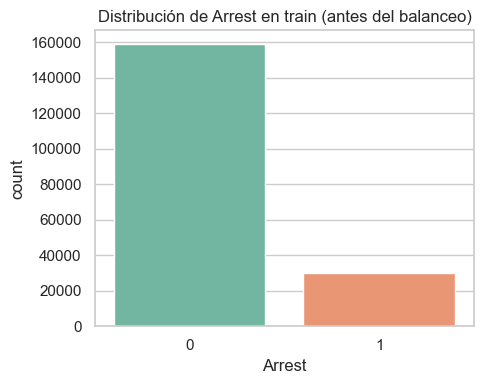

Arrest
0    0.8401
1    0.1599
Name: proportion, dtype: float64


In [18]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=y_train, hue=y_train, palette='Set2', ax=ax, legend=False)
ax.set_title('Distribución de Arrest en train (antes del balanceo)')
ax.set_xlabel('Arrest')
plt.tight_layout()
plt.show()

print(y_train.value_counts(normalize=True).round(4))


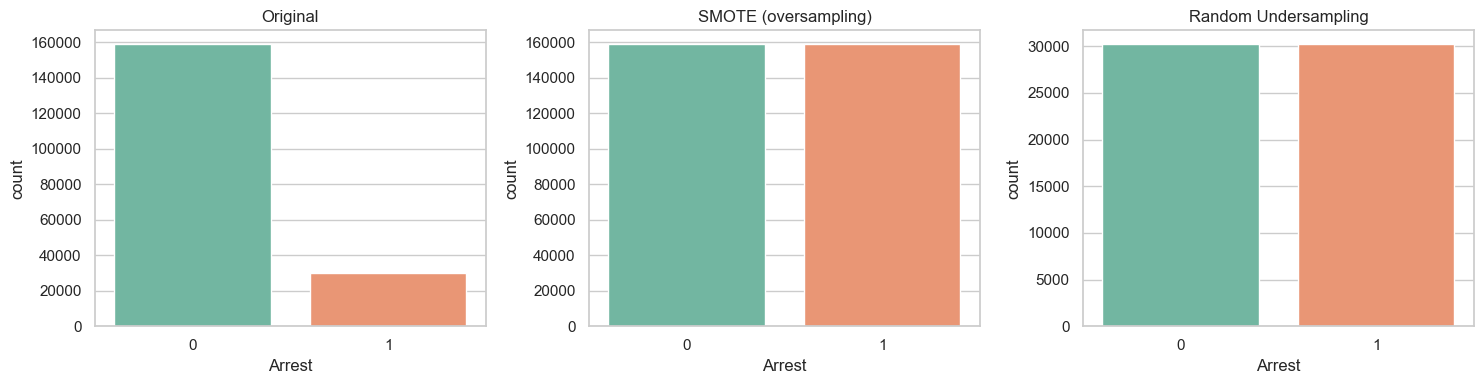

Antes  → {0: 158725, 1: 30203}
SMOTE  → {0: 158725, 1: 158725}
RUS    → {0: 30203, 1: 30203}


In [19]:
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_std, y_train)

# Referencia alternativa
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_us, y_train_us = rus.fit_resample(X_train_std, y_train)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x=y_train,     hue=y_train,     palette='Set2', ax=axes[0], legend=False)
sns.countplot(x=y_train_bal, hue=y_train_bal, palette='Set2', ax=axes[1], legend=False)
sns.countplot(x=y_train_us,  hue=y_train_us,  palette='Set2', ax=axes[2], legend=False)
axes[0].set_title('Original')
axes[1].set_title('SMOTE (oversampling)')
axes[2].set_title('Random Undersampling')
plt.tight_layout()
plt.show()

print(f'Antes  → {dict(y_train.value_counts())}')
print(f'SMOTE  → {dict(pd.Series(y_train_bal).value_counts())}')
print(f'RUS    → {dict(pd.Series(y_train_us).value_counts())}')


---
## 11. Selección de features (filtros)

Se evalúan tres filtros complementarios:

1. **Correlación entre features** (Pearson, Spearman, Kendall) para detectar redundancia.
2. **`VarianceThreshold`** para descartar features con varianza despreciable.
3. **`SelectKBest`** con tres estadísticos:
   - `chi2` (requiere features no negativos → usamos `X_train_mm`)
   - `f_classif` (ANOVA numérico vs. target categórico)
   - `mutual_info_classif` (captura no-linealidad)

Comparando los rankings de los tres podemos identificar features que son robustamente útiles en múltiples criterios.

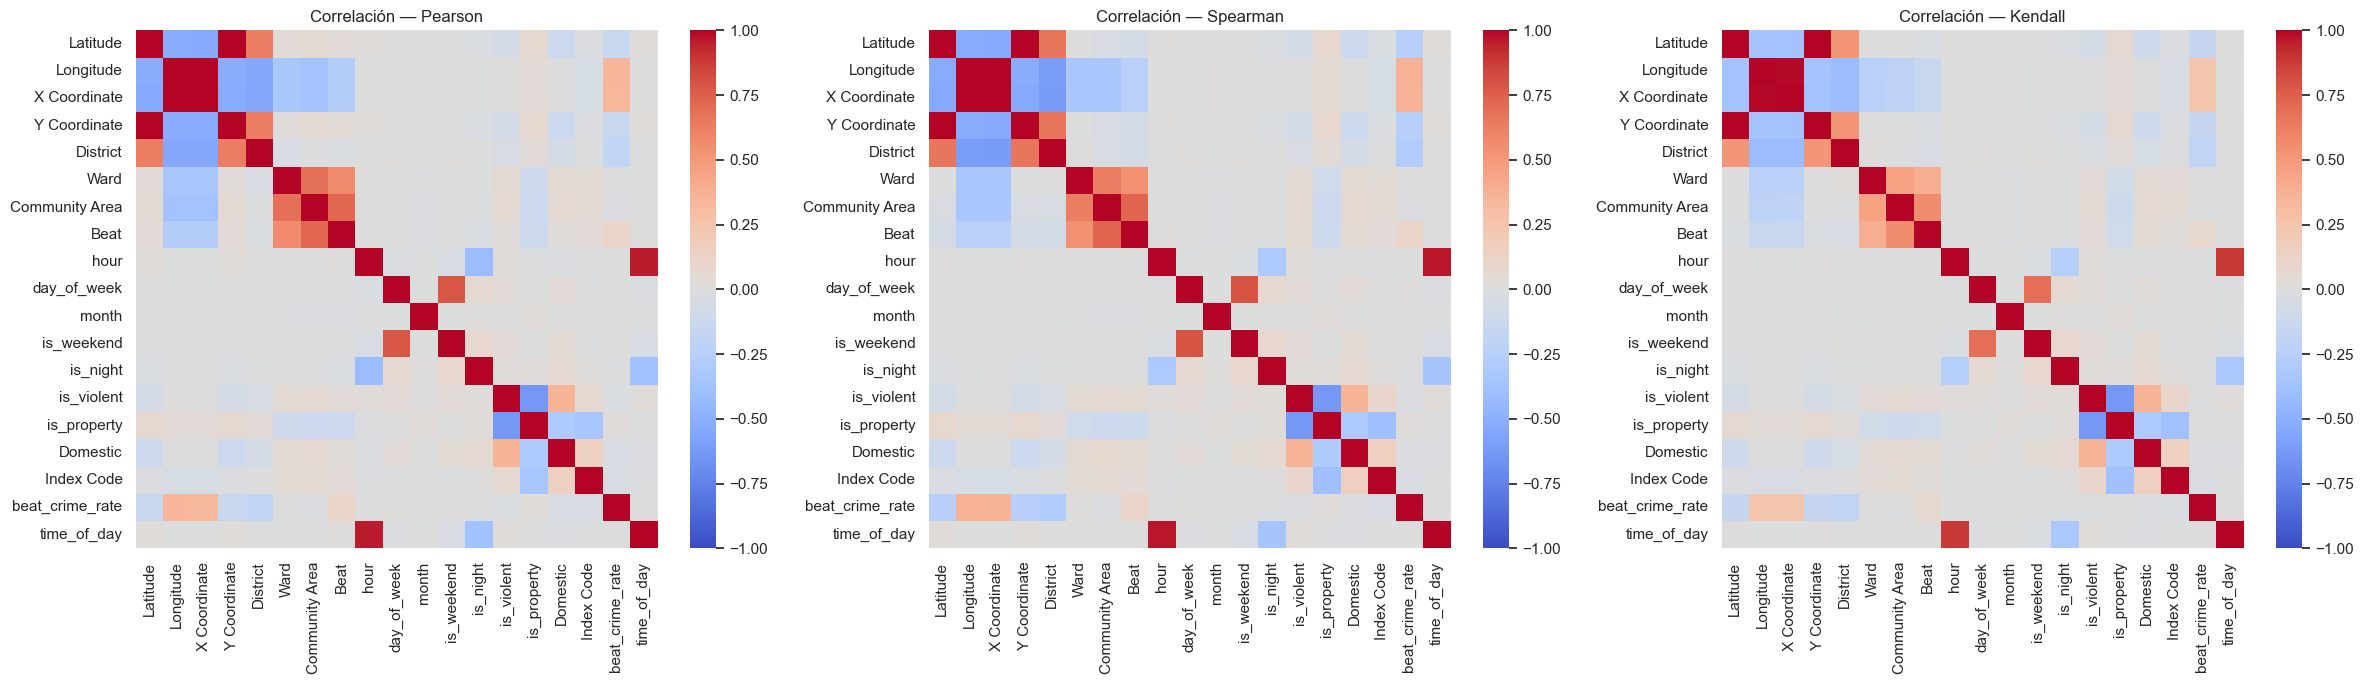

In [20]:
# Heatmap de correlaciones — muestreamos para que sea legible
sample_cols = [
    'Latitude', 'Longitude', 'X Coordinate', 'Y Coordinate',
    'District', 'Ward', 'Community Area', 'Beat',
    'hour', 'day_of_week', 'month', 'is_weekend', 'is_night',
    'is_violent', 'is_property', 'Domestic', 'Index Code',
    'beat_crime_rate', 'time_of_day',
]
sample_cols = [c for c in sample_cols if c in X_train_std.columns]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
for ax, method in zip(axes, ['pearson', 'spearman', 'kendall']):
    corr = X_train_std[sample_cols].corr(method=method)
    sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title(f'Correlación — {method.capitalize()}')
plt.tight_layout()
plt.show()


In [21]:
# Pares con |corr| alta (Pearson), como señal de redundancia
corr_p = X_train_std[sample_cols].corr().abs()
pairs = (
    corr_p.where(np.triu(np.ones(corr_p.shape, dtype=bool), k=1))
          .stack().sort_values(ascending=False)
)
pairs[pairs > 0.9].head(15)


Latitude   Y Coordinate    0.999994
Longitude  X Coordinate    0.999912
hour       time_of_day     0.960483
dtype: float64

In [22]:
# VarianceThreshold sobre X_train_std — eliminamos features (casi) constantes
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train_std.select_dtypes(include=[np.number]))
num_cols_std = X_train_std.select_dtypes(include=[np.number]).columns
descartadas_vt = num_cols_std[~vt.get_support()].tolist()
print(f'{len(descartadas_vt)} columnas con var < 0.01:')
print(descartadas_vt[:20])


55 columnas con var < 0.01:
['Primary Type_SEX OFFENSE', 'Primary Type_INTERFERENCE WITH PUBLIC OFFICER', 'Primary Type_OFFENSE INVOLVING CHILDREN', 'Primary Type_HOMICIDE', 'Primary Type_PROSTITUTION', 'Primary Type_ARSON', 'Primary Type_CRIMINAL SEXUAL ASSAULT', 'Primary Type_STALKING', 'Primary Type_PUBLIC PEACE VIOLATION', 'Primary Type_KIDNAPPING', 'Primary Type_INTIMIDATION', 'Primary Type_LIQUOR LAW VIOLATION', 'Primary Type_CONCEALED CARRY LICENSE VIOLATION', 'Primary Type_OBSCENITY', 'Primary Type_HUMAN TRAFFICKING', 'Primary Type_GAMBLING', 'Primary Type_PUBLIC INDECENCY', 'Primary Type_NON-CRIMINAL', 'Primary Type_OTHER NARCOTIC VIOLATION', 'Location Description_PARK PROPERTY']


In [23]:
# SelectKBest — usamos solo columnas numéricas
X_tr_num_mm  = X_train_mm.select_dtypes(include=[np.number]).fillna(0)
X_tr_num_std = X_train_std.select_dtypes(include=[np.number]).fillna(0)

K = 20

sel_chi2  = SelectKBest(score_func=chi2,                k=K).fit(X_tr_num_mm,  y_train)
sel_anova = SelectKBest(score_func=f_classif,           k=K).fit(X_tr_num_std, y_train)
sel_mi    = SelectKBest(score_func=mutual_info_classif, k=K).fit(X_tr_num_std, y_train)

ranking = pd.DataFrame({
    'chi2':     pd.Series(sel_chi2.scores_,  index=X_tr_num_mm.columns),
    'f_classif':pd.Series(sel_anova.scores_, index=X_tr_num_std.columns),
    'mutual_info': pd.Series(sel_mi.scores_, index=X_tr_num_std.columns),
}).fillna(0)

top = (
    ranking.rank(ascending=False)
           .assign(rank_medio=lambda r: r.mean(axis=1))
           .sort_values('rank_medio').head(K)
)
top.round(2)


,chi2,f_classif,mutual_info,rank_medio
IUCR Secondary,4.0,1.0,1.0,2.00
IUCR Primary_NARCOTICS,1.5,2.5,2.0,2.00
Primary Type_NARCOTICS,1.5,2.5,4.0,2.67
FBI Code_18,3.0,4.0,3.0,3.33
is_property,8.0,8.0,5.0,7.00
FBI Code_15,5.0,5.0,12.0,7.33
Primary Type_WEAPONS VIOLATION,6.5,6.5,13.0,8.67
IUCR Primary_WEAPONS VIOLATION,6.5,6.5,14.0,9.00
FBI Code_06,16.0,16.0,17.0,16.33
Primary Type_CRIMINAL DAMAGE,13.0,18.0,23.0,18.00


Los tres estadísticos miden cosas distintas (asociación χ², varianza explicada lineal, información mutua no-lineal). Un feature que aparece en los tres rankings es un candidato robusto para el modelo final.

---
## 12. Extracción de features — PCA

**Requisitos y supuestos:**

- PCA es **no supervisado** → ignora `y`.
- Exige features numéricas **escaladas** (varianza comparable entre variables). Usamos `X_train_std` / `X_test_std`.
- Asume relaciones **lineales** entre variables; aporta poco si la estructura es muy no lineal.

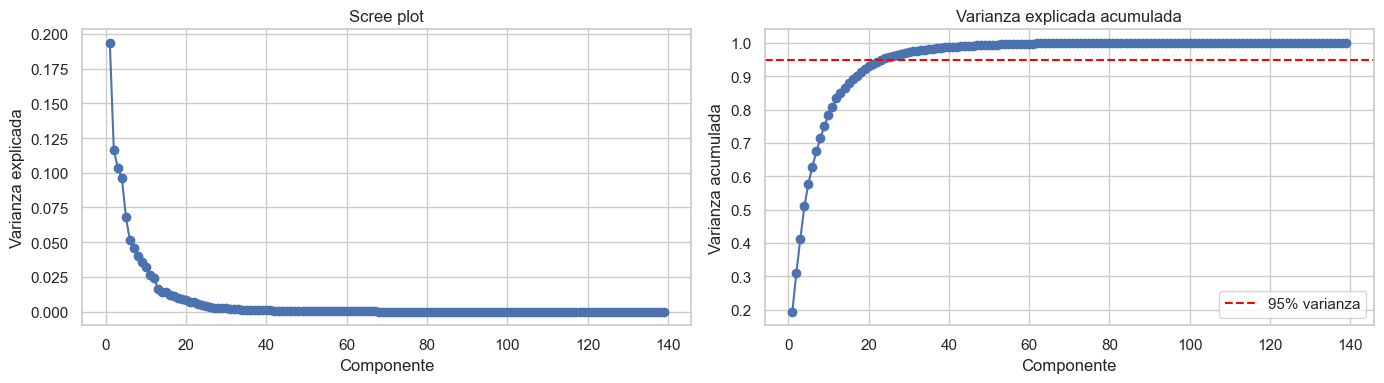

In [24]:
X_tr_pca = X_train_std.select_dtypes(include=[np.number]).fillna(0)
X_te_pca = X_test_std.select_dtypes(include=[np.number]).fillna(0)
X_te_pca = X_te_pca[X_tr_pca.columns]

pca_full = PCA().fit(X_tr_pca)
exp_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var)
componentes = np.arange(1, len(exp_var) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(componentes, exp_var, marker='o')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Varianza explicada')
axes[0].set_title('Scree plot')
axes[0].grid(True)

axes[1].plot(componentes, cum_var, marker='o')
axes[1].axhline(0.95, color='red', linestyle='--', label='95% varianza')
axes[1].set_xlabel('Componente')
axes[1].set_ylabel('Varianza acumulada')
axes[1].set_title('Varianza explicada acumulada')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()


In [25]:
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_tr_pca)
X_test_pca  = pca.transform(X_te_pca)

print(f'Componentes para retener 95% de varianza: {pca.n_components_}')
print(f'X_train_pca: {X_train_pca.shape} | X_test_pca: {X_test_pca.shape}')


Componentes para retener 95% de varianza: 24
X_train_pca: (188928, 24) | X_test_pca: (47233, 24)


In [26]:
# Loadings (cargas) de los primeros 5 componentes
loadings = pd.DataFrame(
    pca.components_[:5].T,
    columns=[f'PC{i+1}' for i in range(5)],
    index=X_tr_pca.columns,
)
# Top contribuciones por componente (en valor absoluto)
for c in loadings.columns:
    top5 = loadings[c].abs().sort_values(ascending=False).head(5).index
    print(f'\n{c} — top contribuciones:')
    print(loadings.loc[top5, c].round(3))



PC1 — top contribuciones:
X Coordinate   -0.385
Longitude      -0.383
lon_bin        -0.381
Latitude        0.329
Y Coordinate    0.328
Name: PC1, dtype: float64

PC2 — top contribuciones:
Community Area                0.429
Community Area Description    0.429
Beat                          0.385
Ward                          0.368
Y Coordinate                 -0.263
Name: PC2, dtype: float64

PC3 — top contribuciones:
month                         0.569
day_of_year                   0.568
quarter                       0.563
Community Area                0.083
Community Area Description    0.083
Name: PC3, dtype: float64

PC4 — top contribuciones:
time_of_day      -0.588
hour             -0.574
hour_sin          0.535
is_night          0.118
IUCR Secondary   -0.078
Name: PC4, dtype: float64

PC5 — top contribuciones:
day_of_week    0.678
dow_sin       -0.628
is_weekend     0.256
dow_cos       -0.239
hour_cos       0.111
Name: PC5, dtype: float64


### 12.1 Ventajas y desventajas de PCA

**Ventajas:**

- Reduce la dimensión conservando la mayor parte de la varianza del dataset.
- Descorrelaciona las features (los componentes son ortogonales), mitigando la multicolinealidad.
- Puede acelerar el entrenamiento en modelos sensibles a la dimensión.

**Desventajas:**

- Los componentes son combinaciones lineales de features originales → **pierde interpretabilidad**.
- Asume relaciones **lineales**; si la estructura del problema es fuertemente no lineal, PCA aporta poco.
- Es **sensible al escalado**: features no estandarizadas dominan la varianza.
- Es **no supervisado**: puede descartar información útil para predecir `Arrest` si esta información vive en direcciones de baja varianza.

---
## 13. Conclusiones y persistencia de artefactos

### Resumen de impacto dimensional

In [27]:
resumen = pd.DataFrame([
    ['1. Dataset enriquecido (post-merge)', df_chicago.shape[1]],
    ['2. Tras limpieza general',             df_clean.shape[1] - 1],  # -1 por el target
    ['7. Tras codificación (OHE + TE)',      X_train.shape[1]],
    ['9. Tras escalado (std)',               X_train_std.shape[1]],
    ['10. Tras SMOTE (train balanceado)',    X_train_bal.shape[1]],
    ['12. Tras PCA (95% varianza)',          pca.n_components_],
], columns=['Etapa', 'Nº features'])
resumen


,Etapa,Nº features
0,1. Dataset enriquecido (post-merge),27
1,2. Tras limpieza general,19
2,7. Tras codificación (OHE + TE),139
3,9. Tras escalado (std),139
4,10. Tras SMOTE (train balanceado),139
5,12. Tras PCA (95% varianza),24


### Discusión

- **Filtros vs. PCA.** Los filtros (`VarianceThreshold`, `SelectKBest`) preservan la interpretabilidad de las variables originales y son preferibles cuando se quiere explicar las predicciones. PCA reduce más agresivamente la dimensión pero sacrifica interpretabilidad, y al ser no supervisado puede descartar información útil para la clasificación.
- **SMOTE vs. `class_weight`.** Se optó por SMOTE porque genera ejemplos sintéticos de la clase minoritaria sin descartar información de la mayoritaria. Como alternativa, muchos clasificadores (`LogisticRegression`, `RandomForestClassifier`) soportan `class_weight='balanced'` y pueden compararse en un paso de modelado posterior.
- **Data leakage.** Todos los transformadores (`SimpleImputer`, `OneHotEncoder`, `TargetEncoder`, `StandardScaler`, `MinMaxScaler`, `KBinsDiscretizer`, `PCA`) fueron ajustados **solo sobre `X_train`** y aplicados al test sin reajustarlos. SMOTE se aplicó únicamente al train.

### Persistencia

Guardamos los datasets preprocesados para usarlos en trabajos posteriores.

In [28]:
from pathlib import Path
out_dir = Path('processed')
out_dir.mkdir(exist_ok=True)

# Usamos pickle (robusto a extension dtypes y sin dependencias extra)
def _dedup(cols):
    seen, out = {}, []
    for c in cols:
        if c in seen:
            seen[c] += 1
            out.append(f'{c}__{seen[c]}')
        else:
            seen[c] = 0
            out.append(c)
    return out

cols_bal = _dedup(list(X_train_std.columns))
pd.DataFrame(X_train_bal, columns=cols_bal).to_pickle(out_dir / 'X_train_bal.pkl')
pd.Series(y_train_bal, name='Arrest').to_pickle(out_dir / 'y_train_bal.pkl')
X_test_std.to_pickle(out_dir / 'X_test_std.pkl')
y_test.to_pickle(out_dir / 'y_test.pkl')

# Versión PCA
pc_cols = [f'PC{i+1}' for i in range(pca.n_components_)]
pd.DataFrame(X_train_pca, columns=pc_cols).to_pickle(out_dir / 'X_train_pca.pkl')
pd.DataFrame(X_test_pca,  columns=pc_cols).to_pickle(out_dir / 'X_test_pca.pkl')

print(f'Archivos guardados en {out_dir.resolve()}')
for p in sorted(out_dir.iterdir()):
    print(' -', p.name)


Archivos guardados en /Users/francomorero/PycharmProjects/franco/ceia-analisis-de-datos-tp-final/processed
 - X_test_pca.pkl
 - X_test_std.pkl
 - X_train_bal.pkl
 - X_train_pca.pkl
 - y_test.pkl
 - y_train_bal.pkl


### Checklist contra la consigna

| Requerimiento | Sección |
|---|---|
| Limpieza general del dataset | §2 |
| Split train / test | §3 |
| Valores faltantes | §4 |
| Outliers | §5 |
| Escalado / normalización | §9 |
| Creación de nuevos features | §6 |
| Codificación | §7 |
| Discretización | §8 |
| Balance / desbalance de clases | §10 |
| Selección de features (filtros) | §11 |
| Extracción de features (PCA) | §12 |
